In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import math
import torch
import matplotlib.pyplot as plt

def find_repo_root(start_path=None):
    current = (start_path or Path.cwd()).resolve()
    while True:
        if (current / "data").is_dir() and (current / "data_setup").is_dir():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise RuntimeError("Could not locate necst-torch root directory")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.utils import build_dataloaders

train_loader, valid_loader, test_loader, input_dim = build_dataloaders(
    dataset_name="binarymnist",
    datadir=str(REPO_ROOT / "data"),
    batch_size=100,
)

# quick sanity check
batch = next(iter(train_loader))
print("Train batch shape:", batch.shape, "min/max:", batch.min().item(), batch.max().item())


Train batch shape: torch.Size([100, 1, 28, 28]) min/max: 0.0 1.0


In [2]:
### noise 0.0 -- load model
import torch
from pathlib import Path
from src.necst import NecstTorch
from src.args import parse_architecture

ckpt_path = Path("../../models/mnist_vimco_0.0.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(ckpt_path, map_location=device)
config = checkpoint.get("config", {})
state_dict = checkpoint.get("model_state", checkpoint)

# rebuild model with saved config (fallbacks if keys missing)
model = NecstTorch(
    input_dim=config.get("input_dim", 784),
    z_dim=config.get("latent_dim", 100),
    vimco_samples=config.get("vimco_samples", 5),
    noise=config.get("noise", 0.0),
    test_noise=config.get("test_noise", 0.0),
    encoder_layers=parse_architecture(config.get("enc_arch", "500")),
    decoder_layers=parse_architecture(config.get("dec_arch", "500,500")),
).to(device)

model.load_state_dict(state_dict)
model.eval()
print("Loaded model from", ckpt_path)

Loaded model from ../../models/mnist_vimco_0.0.pt


Test BCE per pixel: 0.064625 | per image: 50.682995


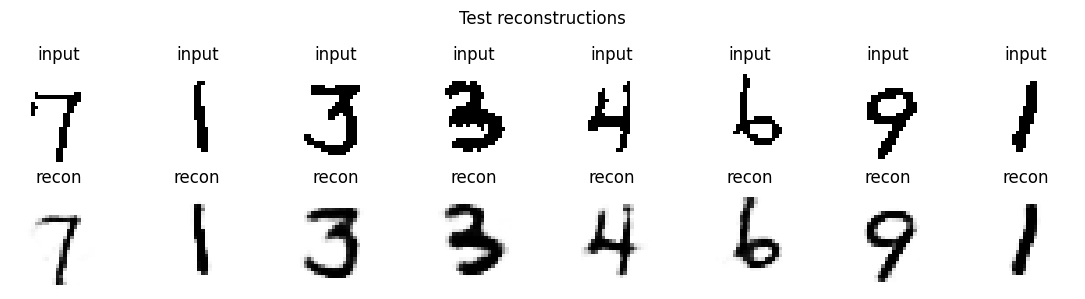

In [3]:
### noise 0.0

# load model

# test error (per sample/per image)
loss_per_pixel = model.evaluate_reconstruction(test_loader, per_element=True)
loss_per_image = model.evaluate_reconstruction(test_loader, per_element=False)
print(f"Test BCE per pixel: {loss_per_pixel:.6f} | per image: {loss_per_image:.6f}")


# image reconstructions
fig = model.plot_reconstructions(test_loader, n_samples=8, title="Test reconstructions")
plt.show()

two images selected:


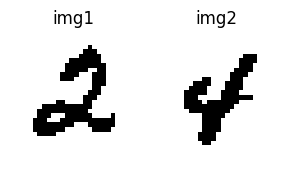

7 --> 2:


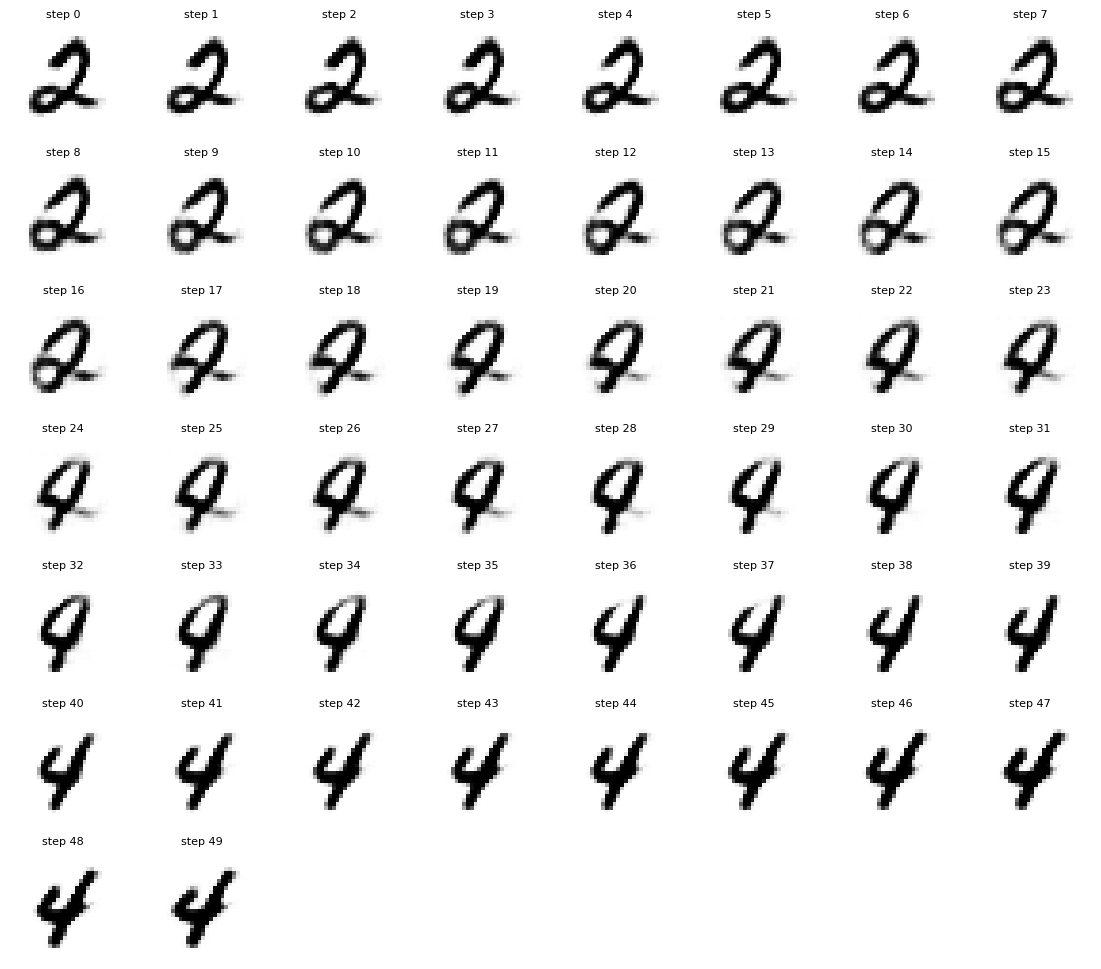

In [9]:
### latent interpolation

# get model
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# from a DataLoader
# batch = next(iter(test_loader))
# imgs = batch if not isinstance(batch, (list, tuple)) else batch[0]
# img1, img2 = imgs[:2].to(device)

ds = test_loader.dataset
idx = torch.randperm(len(ds))[:2]
img1 = ds[idx[5]][0] if isinstance(ds[idx[0]], (list, tuple)) else ds[idx[0]]
img2 = ds[idx[99]][0] if isinstance(ds[idx[1]], (list, tuple)) else ds[idx[1]]
img1, img2 = img1.to(device), img2.to(device)

print('two images selected:')
fig, axes = plt.subplots(1, 2, figsize=(3, 2))
axes[0].imshow(img1.view(28, 28).cpu(), cmap="gray_r", vmin=0, vmax=1)
axes[0].axis("off"); axes[0].set_title("img1")
axes[1].imshow(img2.view(28, 28).cpu(), cmap="gray_r", vmin=0, vmax=1)
axes[1].axis("off"); axes[1].set_title("img2")
plt.tight_layout()
plt.show()


# sample binary latents for each image
print('7 --> 2:')
with torch.no_grad():
    y1, _, _ = model.forward_test(img1.unsqueeze(0))  # (1, z_dim)
    y2, _, _ = model.forward_test(img2.unsqueeze(0))  # (1, z_dim)

y1_vec = y1.squeeze(0).clone()
y2_vec = y2.squeeze(0).clone()
z_dim = y1_vec.numel()

# collect decoded images for y1 as bits are flipped toward y2
recons = []

def decode_bits(z_bits):
    logits = model.decoder(z_bits.unsqueeze(0))
    return torch.sigmoid(logits).view(28, 28).cpu()

with torch.no_grad():
    recons.append(decode_bits(y1_vec))  # starting image
    for i in range(z_dim):
        if y1_vec[i].item() != y2_vec[i].item():
            y1_vec[i] = y2_vec[i]  # flip toward target
            recons.append(decode_bits(y1_vec))

# plot recons: 8 per row
n = len(recons)
cols = 8
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.4))
axes = axes.flatten()
for idx, img in enumerate(recons):
    axes[idx].imshow(img, cmap="gray_r", vmin=0, vmax=1)
    axes[idx].axis("off")
    axes[idx].set_title(f"step {idx}", fontsize=8)
# hide unused axes
for ax in axes[len(recons):]:
    ax.axis("off")
plt.tight_layout()
plt.show()